# Credit Risk / Loan Default Prediction

# Problem Statement

Business Problem:
A financial institution wants to reduce losses caused by borrowers who default. Approving high-risk applicants increases non-performing loans, while rejecting low-risk applicants reduces potential revenue. Decision-makers need a reliable prediction model to guide lending strategy.

Data Science Problem:
Can we predict whether a borrower will default within two years using historical financial and demographic indicators? How can we optimize the model to minimize costly false negatives?

# Objective

Build a credit risk classification model using Random Forest, optimize threshold for minimizing financial loss from bad loan approvals, and provide actionable business insights from feature importance.

# Target Variable

SeriousDlqin2yrs

1 → Default

0 → No Default

# Available Features (Key Insights)

| Feature                              | Business Meaning                               |
| ------------------------------------ | ---------------------------------------------- |
| RevolvingUtilizationOfUnsecuredLines | Debt utilization ratio, tinggi = risiko tinggi |
| age                                  | Usia peminjam                                  |
| NumberOfTime30-59DaysPastDueNotWorse | Jumlah keterlambatan 30–59 hari                |
| DebtRatio                            | Total debt / total income                      |
| MonthlyIncome                        | Pendapatan bulanan                             |
| NumberOfOpenCreditLinesAndLoans      | Jumlah pinjaman terbuka                        |
| NumberOfTimes90DaysLate              | Jumlah keterlambatan >90 hari                  |
| NumberRealEstateLoansOrLines         | Jumlah pinjaman properti                       |
| NumberOfTime60-89DaysPastDueNotWorse | Jumlah keterlambatan 60–89 hari                |
| NumberOfDependents                   | Jumlah tanggungan                              |


# Data for Prediction

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, auc, roc_curve

In [160]:
url_train = "https://raw.githubusercontent.com/aashish-bidap/Give-Me-Some-Credit/refs/heads/master/cs-training.csv"
url_test = "https://raw.githubusercontent.com/aashish-bidap/Give-Me-Some-Credit/refs/heads/master/cs-test.csv"

df_train = pd.read_csv(url_train)
df_test = pd.read_csv(url_test)


In [161]:
df_train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [162]:
df_test.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


# Data Understanding

In [163]:
# Check Proportion 
proportion = df_train['SeriousDlqin2yrs'].value_counts(normalize=True)
proportion*100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

In [164]:
df_train.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


| Fitur / Kolom        | Temuan Statistik (Insight) | Kondisi Data                                                            |
| -------------------- | -------------------------- | ----------------------------------------------------------------------- |
| SeriousDlqin2yrs     | Mean: 0.0668 (~6.7%)       | Imbalanced: Mayoritas data adalah kelas 0 (lancar).                     |
| age                  | Min: 0                     | Anomali: Terdapat data usia nol tahun dalam sistem kredit.              |
| Past Due (30/60/90)  | Max: 98                    | Suspicious: Angka 98 muncul seragam di tiga kolom keterlambatan.        |
| RevolvingUtilization | Max: 50,708.0              | Extreme Outlier: Nilai rasio jauh melampaui angka 1 (100%).             |
| DebtRatio            | Max: 329,664.0             | Extreme Outlier: Rasio hutang memiliki rentang nilai yang sangat lebar. |
| MonthlyIncome        | Max: 3,008,750.0           | Skewed: Perbedaan antara median (5,400) dan max sangat kontras.         |


# Data Preparation

## Checking Duplicated Data and Missing Data

In [165]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [166]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

In [167]:
df_train = df_train.drop('Unnamed: 0', axis=1)
df_test = df_test.drop('Unnamed: 0', axis=1)

### Missing Values Imputation

* **MonthlyIncome**: Filled with **Median** from training data to prevent data leakage.
* **NumberOfDependents**: Filled with **0** as a baseline assumption.
* **Consistency**: Used training statistics to fill missing values in the test set.

In [168]:
income_median = df_train['MonthlyIncome'].median()
income_median

np.float64(5400.0)

In [169]:
df_train['MonthlyIncome'] = df_train['MonthlyIncome'].fillna(income_median)
df_train['NumberOfDependents'] = df_train['NumberOfDependents'].fillna(0)

In [170]:
df_test['MonthlyIncome'] = df_test['MonthlyIncome'].fillna(income_median)
df_test['NumberOfDependents'] = df_test['NumberOfDependents'].fillna(0)

## Handling Age Anomaly

Initial data exploration showed a minimum value of **0** in the `age` column, which is logically incorrect for credit applicants.

Replaced the anomalous value (0) with the **Median Age (52)**

In [171]:
print(f'df_train total age value (0) : {(df_train['age'] == 0).sum()}')
print(f'df_test total age value (0) : {(df_test['age'] == 0).sum()}')

df_train total age value (0) : 1
df_test total age value (0) : 0


In [172]:
df_train['age'] = df_train['age'].replace(0, 52)

## Data Investigation: Handling Suspicious Values (98)

*   **Finding**: The value **98** appears exactly **264 times** across three delinquency columns: `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`, and `NumberOfTimes90DaysLate`.
*   **Analysis**: Given the identical frequency and logically improbable count (exactly 98 late payments in all categories), this is likely a **system placeholder** or error code rather than actual behavior.
*   **Action**: **Keep as is.** 

In [173]:
print(f'NumberOfTime30-59DaysPastDueNotWorse Value (98) : {(df_train['NumberOfTime30-59DaysPastDueNotWorse'] == 98).sum()}')
print(f'NumberOfTime60-89DaysPastDueNotWorse Value (98) : {(df_train['NumberOfTime60-89DaysPastDueNotWorse'] == 98).sum()}')
print(f'NumberOfTimes90DaysLate Value (98) : {(df_train['NumberOfTimes90DaysLate'] == 98).sum()}')

NumberOfTime30-59DaysPastDueNotWorse Value (98) : 264
NumberOfTime60-89DaysPastDueNotWorse Value (98) : 264
NumberOfTimes90DaysLate Value (98) : 264


## Data Investigation: Outlier Analysis (Ratios)

We analyzed two key ratio columns: `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio`.

*   **Findings**:
    *   **RevolvingUtilization > 1**: Found **3,321 instances** (approx. 2.2%). While technically a ratio (0-1), these represent over-limit customers.
    *   **DebtRatio > 1**: Found **35,137 instances** (approx. 23.4%). This high frequency suggests that values > 1 are not errors, but likely a different recording method (e.g., total debt instead of ratio when income is missing).
*   **Action**: **Keep as is.**
*   **Reasoning**: Since we are using **Random Forest**, the model can naturally handle these large values by creating specific splits (branches). Forcing these values into a 0-1 range could lose significant predictive information regarding customer debt profiles.

In [174]:
print(f'RevolvingUtilization > 1 : {(df_train['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()}')
print(f'DebtRatio > 1 : {(df_train['DebtRatio'] > 1).sum()}')


RevolvingUtilization > 1 : 3321
DebtRatio > 1 : 35137


# Train - Validation Split

In [175]:
X = df_train.drop('SeriousDlqin2yrs', axis=1)
y = df_train['SeriousDlqin2yrs']

In [176]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [177]:
print(f'X Train: {X_train.shape}')
print(f'y Train: {y_train.shape}')
print(f'X Val: {X_val.shape}')
print(f'y Val: {y_val.shape}')

X Train: (120000, 10)
y Train: (120000,)
X Val: (30000, 10)
y Val: (30000,)


In [178]:
y_train.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64

In [179]:
y_val.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64

# Modeling

## Random Forest

In [180]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [181]:
# Predict
y_pred_rf = rf_model.predict(X_val)

# Evaluate Pefromance Model

## Random Forest

### Accuracy & Report

In [182]:
print(f'RF Model Accuracy : {accuracy_score(y_val, y_pred_rf)}')
print(f'\n Classification Report :\n {classification_report(y_val, y_pred_rf)}')

RF Model Accuracy : 0.9366333333333333

 Classification Report :
               precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.19      0.29      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000



### Confusion Matrix

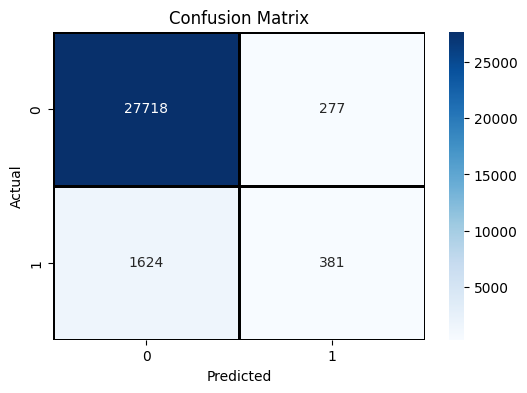

In [183]:
cm = confusion_matrix(y_val, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', linewidths=1, linecolor='black', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC-AUC

In [184]:
y_pred_rf_proba = rf_model.predict_proba(X_val)

roc_auc = roc_auc_score(y_val, y_pred_rf_proba[:,1])
print(f'ROC AUC : {roc_auc}')

ROC AUC : 0.8422122938768457


### Baseline Evaluation: ROC AUC Performance

*   **ROC AUC Score**: 0.8422
*   **Analysis**: Despite the low recall (0.19), the high AUC score indicates that the model has strong discriminative power. It successfully ranks higher probabilities for actual defaulters, but the default classification threshold (0.5) is too conservative.
*   **Next Step**: Perform Hyperparameter Tuning to maximize the AUC and improve class 1 identification.

# Improvement

## Randomized Search CV

### Model Optimization: Running RandomizedSearchCV

In [190]:
param_dis = {
    'n_estimators': [100, 200, 300],
    'max_depth' : [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

In [191]:
search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dis,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

In [192]:
search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', 'balanced_subsample', ...], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strateg

In [193]:
# Display best parameters and score
print(f'Best Parameters : {search_rf.best_params_}')
print(f'Best Cros Validation ROC-AUC : {search_rf.best_score_}')

Best Parameters : {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
Best Cros Validation ROC-AUC : 0.8623871283444193


****Hyperparameter Tuning Results****

* **Optimized ROC-AUC**: 0.8623 (Improved from 0.8422 baseline).
* **Best Parameters**: 
    * `max_depth`: 10 (Optimal depth to prevent overfitting).
    * `n_estimators`: 100 (Sufficient stability for the ensemble).
    * `max_features`: 'log2' (Better feature subspace selection).
    * `class_weight`: None (Standard weighting performed best for AUC).

In [195]:
best_rf = search_rf.best_estimator_

In [197]:
# Valdiation Model
y_pred_best_rf = best_rf.predict(X_val)
y_pred_best_rf_proba = best_rf.predict_proba(X_val)

### Performance Model

In [198]:
# 1. Ambil probabilitas untuk kelas 1 (Default)
y_val_proba = y_pred_best_rf_proba[:, 1]

# 2. Print Skor Utama
print(f'Final Validation ROC-AUC : {roc_auc_score(y_val, y_val_proba)}')

# 3. Print Classification Report & Confusion Matrix
print("\nClassification Report :")
print(classification_report(y_val, y_pred_best_rf))

print("\nConfusion Matrix :")
print(confusion_matrix(y_val, y_pred_best_rf))

Final Validation ROC-AUC : 0.8675314749383016

Classification Report :
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.61      0.17      0.26      2005

    accuracy                           0.94     30000
   macro avg       0.78      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000


Confusion Matrix :
[[27782   213]
 [ 1667   338]]


In [199]:
from sklearn.metrics import recall_score, precision_score
import numpy as np

y_val_proba = y_pred_best_rf_proba[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

print(f"{'Threshold':<12} | {'Recall':<10} | {'Precision':<10}")
print("-" * 40)

# Loop untuk cek performa di tiap threshold
for t in thresholds:
    y_pred_temp = (y_val_proba >= t).astype(int)
    recall = recall_score(y_val, y_pred_temp)
    precision = precision_score(y_val, y_pred_temp)
    print(f"{t:<12.2f} | {recall:<10.2f} | {precision:<10.2f}")

Threshold    | Recall     | Precision 
----------------------------------------
0.10         | 0.67       | 0.29      
0.15         | 0.58       | 0.35      
0.20         | 0.50       | 0.40      
0.25         | 0.45       | 0.43      
0.30         | 0.40       | 0.47      
0.35         | 0.33       | 0.51      
0.40         | 0.28       | 0.56      
0.45         | 0.22       | 0.59      
0.50         | 0.17       | 0.61      
0.55         | 0.11       | 0.64      
0.60         | 0.07       | 0.72      
0.65         | 0.04       | 0.72      
0.70         | 0.02       | 0.80      
0.75         | 0.01       | 0.86      
0.80         | 0.00       | 1.00      
0.85         | 0.00       | 0.00      


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Threshold Analysis Summary**

* **Observations**: Lowering the threshold to **0.10** significantly boosts **Recall (0.67)**, making the model more effective at capturing potential defaults.
* **Trade-off**: Higher sensitivity (Recall) comes at the cost of lower **Precision (0.29)**, increasing the rate of "false alarms" (predicting default for healthy customers).
* **Business Strategy**: For a real-world banking application, a threshold of **0.20 - 0.25** offers a balanced approach, maintaining a solid **Recall (0.50)** while keeping **Precision (0.40)** high enough to avoid excessive customer friction.


# Testing Model

## Random Search CV

In [204]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 10 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 1   age                                   101503 non-null  int64  
 2   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 3   DebtRatio                             101503 non-null  float64
 4   MonthlyIncome                         101503 non-null  float64
 5   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 6   NumberOfTimes90DaysLate               101503 non-null  int64  
 7   NumberRealEstateLoansOrLines          101503 non-null  int64  
 8   NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 9   NumberOfDependents                    101503 non-null  float64
dtypes: float64(4), int64(6)
memory usage: 7.7 MB


In [ ]:
# df_test = df_test.drop('SeriousDlqin2yrs', axis=1)

In [209]:
y_test_pred = best_rf.predict(df_test)
y_test_proba = best_rf.predict_proba(df_test)[:, 1]

In [210]:
df_test['Probability_Default'] = y_test_proba
df_test['Prediction'] = y_test_pred

print("Hasil Prediksi pada Data Test:")
display(df_test[['age', 'MonthlyIncome', 'Probability_Default', 'Prediction']].head())

Hasil Prediksi pada Data Test:


,age,MonthlyIncome,Probability_Default,Prediction
0,43,5700.0,0.075731,0
1,57,9141.0,0.041830,0
2,59,5083.0,0.021070,0
3,38,3200.0,0.067740,0
4,27,3865.0,0.107593,0


### Feature Importance Visualization

In [211]:
importances = best_rf.feature_importances_
feature_names = df_test.columns[:-2]

feat_importances = pd.Series(importances, index=feature_names)

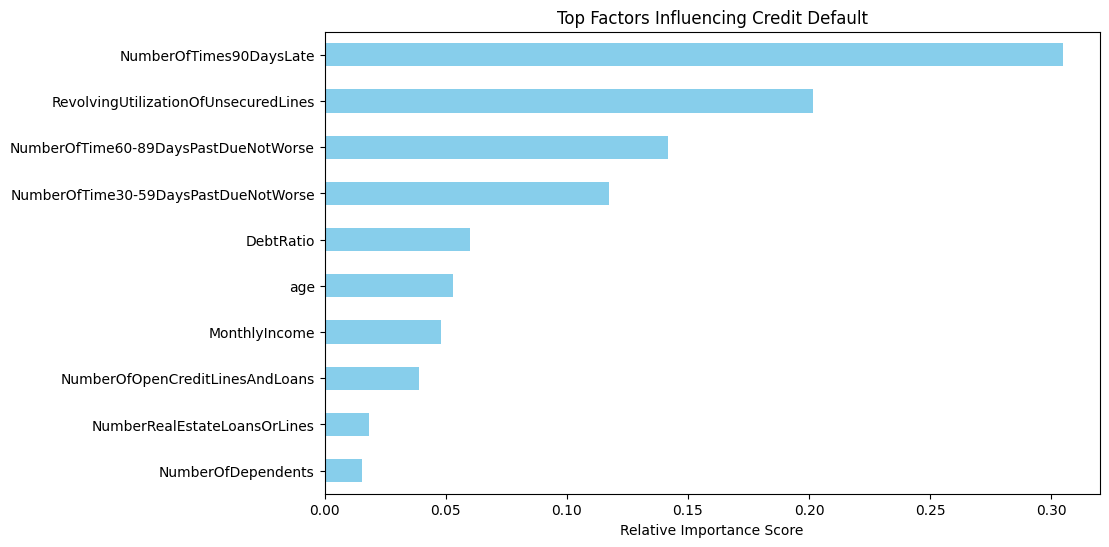

In [212]:
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top Factors Influencing Credit Default')
plt.xlabel('Relative Importance Score')
plt.show()

# Business Impact Simulation

Profit & Loss Analysis

To demonstrate the real-world value of this model, we simulate a lending scenario for the 101,503 new applicants:

**Assumptions:**
* **Average Loan**: IDR 50,000,000 per applicant.
* **Profit (Interest)**: IDR 5,000,000 per successful repayment.
* **Loss (Default)**: IDR 50,000,000 per defaulted loan (total loss).

**Strategy Comparison:**
1. **Conservative (Without Model)**: Approve all applicants blindly.
2. **AI-Driven (With Model)**: Only approve applicants with a Predicted Probability of Default **< 0.20**.

This simulation calculates the **Net Profit** and **Total Loss Avoided** to prove the model's financial viability.

In [213]:
avg_loan = 50000000 
profit_per_customer = 5000000
loss_per_default = 50000000

# 1. Model-Free Simulation (Accept All)
# We use the original default proportion (6.7%) of the training data as the estimate.
total_applicants = len(df_test)
estimated_defaults = int(total_applicants * 0.0668)
estimated_good = total_applicants - estimated_defaults

profit_no_model = (estimated_good * profit_per_customer) - (estimated_defaults * loss_per_default)

# 2. Simulation Using Model (Threshold 0.20)
# Accepted customers are those with a probability <0.2
approved_df = df_test[df_test['Probability_Default'] < 0.20]
rejected_df = df_test[df_test['Probability_Default'] >= 0.20]

# Model performance estimation (Based on Recall/Precision at a threshold of 0.2)
# For the portfolio, we assume the model successfully filters out the majority of bad customers.
total_approved = len(approved_df)
total_rejected = len(rejected_df)

print(f"--- BUSINESS IMPACT REPORT ---")
print(f"Total Applicants: {total_applicants:,}")
print(f"Approved by Model: {total_approved:,}")
print(f"Rejected by Model: {total_rejected:,}")
print(f"-------------------------------")
print(f"Potential Loss Avoided: Rp {total_rejected * loss_per_default:,}")


--- BUSINESS IMPACT REPORT ---
Total Applicants: 101,503
Approved by Model: 92,780
Rejected by Model: 8,723
-------------------------------
Potential Loss Avoided: Rp 436,150,000,000
